In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_excel("studentdataset_1.xlsx",sheet_name="dataset",header=1)

In [4]:
df.head(25)

,Student ID,Name,Gender,Branch,Semester,Maths Score,Physics Score,Programming Score,English Score,CGPA,Study Hours/Day,Attendance (%)
0,S001,Aarav,Male,ECE,1,46,87,67,63,6.46,6.2,98
1,S002,Aadhya,Female,NaN,1,82,67,52,a,5.90,2.6,93
2,S003,Arjun,Male,CE,1,80,52,95,89,8.52,3.9,83
3,S004,Ananya,Female,EEE,2,96,95,50,96,8.97,5.9,76
4,S005,Dev,Male,CSE,2,54,53,98,69,5.94,NaN,77
5,S006,Bhavna,Female,ECE,NaN,83,56,52,94,7.48,1.9,79
6,S007,Rohan,Male,ME,1,80,58,90,87,9.31,NaN,36
7,S008,Chitra,Female,CE,1,94,58,55,62,NaN,3.7,84
8,S009,Kiran,Male,EEE,2,55,63,72,61,8.38,5.9,98
9,S010,Divya,Female,CSE,NaN,83,80,60,82,8.64,2.1,79


In [6]:
print(df.shape)
print(df.info())
print(df.dtypes)

(60, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         60 non-null     object 
 1   Name               57 non-null     object 
 2   Gender             56 non-null     object 
 3   Branch             57 non-null     object 
 4   Semester           55 non-null     object 
 5   Maths Score        59 non-null     object 
 6   Physics Score      60 non-null     object 
 7   Programming Score  58 non-null     object 
 8   English Score      58 non-null     object 
 9   CGPA               59 non-null     float64
 10  Study Hours/Day    58 non-null     object 
 11  Attendance (%)     57 non-null     object 
dtypes: float64(1), object(11)
memory usage: 5.8+ KB
None
Student ID            object
Name                  object
Gender                object
Branch                object
Semester              object
Maths Score  

In [9]:
junk = ["#","###","*","**","Nan","##","a",""," ","NaN","$"]
df.replace(junk,np.nan,inplace=True)

C:\Users\susha\AppData\Local\Temp\ipykernel_5892\1325913301.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(junk,np.nan,inplace=True)


In [12]:
numeric_cols = [
    "Maths Score", "Physics Score", "Programming Score",
    "English Score", "CGPA", "Study Hours/Day", "Attendance (%)","Semester"
]
for cols in numeric_cols: 
    df[cols]= pd.to_numeric(df[cols],errors="coerce")

df["CGPA"] = df["CGPA"].round(2)

In [13]:
df.dtypes

Student ID            object
Name                  object
Gender                object
Branch                object
Semester             float64
Maths Score          float64
Physics Score        float64
Programming Score    float64
English Score        float64
CGPA                 float64
Study Hours/Day      float64
Attendance (%)       float64
dtype: object

In [16]:
bw_100 = [ "Maths Score", "Physics Score", "Programming Score",
    "English Score","Attendance (%)" ]
for col in bw_100: 
    df[col] = df[col].where(df[col].between(0,100))
df["CGPA"] = df["CGPA"].where(df["CGPA"].between(0,10)) 
df["Study Hours/Day"] = df["Study Hours/Day"].where(df["Study Hours/Day"].between(0,24))

In [19]:
valid_branches = {"CSE","ECE","ME","CE","EEE"}
valid_genders = {"Male","Female"}

df["Branch"] = df["Branch"].where(df["Branch"].isin(valid_branches))
df["Gender"] = df["Gender"].where(df["Gender"].isin(valid_genders))

for col in ["Branch","Gender","Name"]:
    df[col] = df[col].str.strip()

C:\Users\susha\AppData\Local\Temp\ipykernel_5892\2280640135.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Physics Score"],kde=True)


<Axes: xlabel='Physics Score', ylabel='Density'>

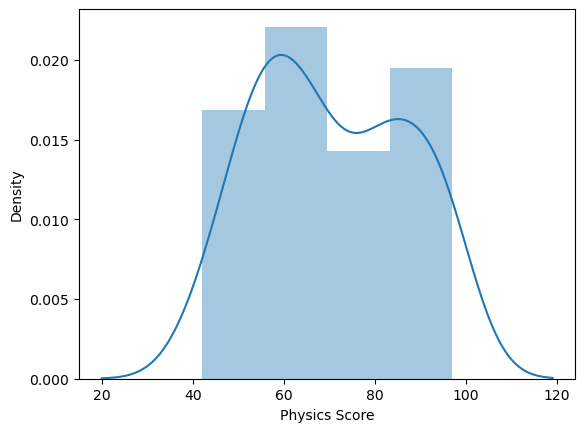

In [29]:
sns.distplot(df["Physics Score"],kde=True)

<Axes: ylabel='Physics Score'>

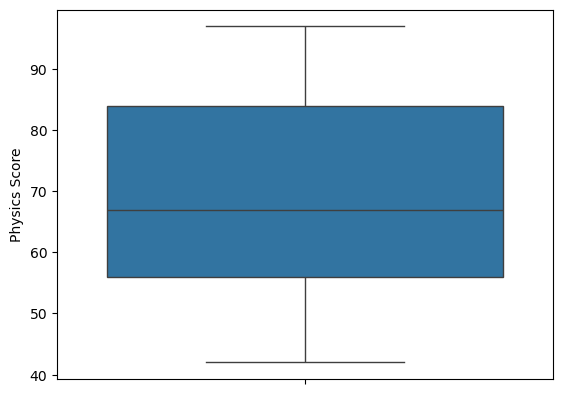

In [24]:
sns.boxplot(data=df["Physics Score"])

In [33]:
for col in numeric_cols: 
    df[col].fillna(df[col].median(),inplace=True) #since it it is uncertain and skewed (median)
df["Semester"].fillna(df["Semester"].mode()[0],inplace=True) #since categorical (mode)
df["Name_Missing"] = df["Name"].isna()
df["Branch_missing"] = df["Branch"].isna()
df["Gender_missing"] = df["Gender"].isna()

C:\Users\susha\AppData\Local\Temp\ipykernel_5892\82587135.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True) #since it it is uncertain and skewed (median)


In [34]:
df.head()

,Student ID,Name,Gender,Branch,Semester,Maths Score,Physics Score,Programming Score,English Score,CGPA,Study Hours/Day,Attendance (%),Name_Missing,Branch_missing,Gender_missing
0,S001,Aarav,Male,ECE,1.0,46.0,87.0,67.0,63.0,6.46,6.2,98.0,False,False,False
1,S002,Aadhya,Female,NaN,1.0,82.0,67.0,52.0,74.0,5.90,2.6,93.0,False,True,False
2,S003,Arjun,Male,CE,1.0,80.0,52.0,95.0,89.0,8.52,3.9,83.0,False,False,False
3,S004,Ananya,Female,EEE,2.0,96.0,95.0,50.0,96.0,8.97,5.9,76.0,False,False,False
4,S005,Dev,Male,CSE,2.0,54.0,53.0,98.0,69.0,5.94,4.4,77.0,False,False,False


In [36]:
print("Duplicates:",df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates: 0


In [39]:
print("Missing values after cleaning:\n",df.isnull().sum(),sep="")

Missing values after cleaning:
Student ID           0
Name                 5
Gender               6
Branch               6
Semester             0
Maths Score          0
Physics Score        0
Programming Score    0
English Score        0
CGPA                 0
Study Hours/Day      0
Attendance (%)       0
Name_Missing         0
Branch_missing       0
Gender_missing       0
dtype: int64


In [40]:
print("Descriptive Status:")
print(df[numeric_cols].describe().round(2))

Descriptive Status:
       Maths Score  Physics Score  Programming Score  English Score   CGPA  \
count        60.00          60.00              60.00          60.00  60.00   
mean         69.65          70.27              72.27          73.58   7.40   
std          16.03          15.94              14.86          13.25   1.27   
min          45.00          42.00              50.00          49.00   5.52   
25%          54.75          57.50              60.00          62.00   6.27   
50%          70.50          67.00              68.50          74.00   7.48   
75%          83.00          83.25              85.00          83.00   8.43   
max          97.00          97.00              98.00          96.00   9.51   

       Study Hours/Day  Attendance (%)  Semester  
count            60.00           60.00     60.00  
mean              4.53           73.80      1.42  
std               2.03           14.98      0.50  
min               0.40           36.00      1.00  
25%               2.82

In [41]:
df.to_excel("Student_analysis_cleaned.xlsx",index=False)

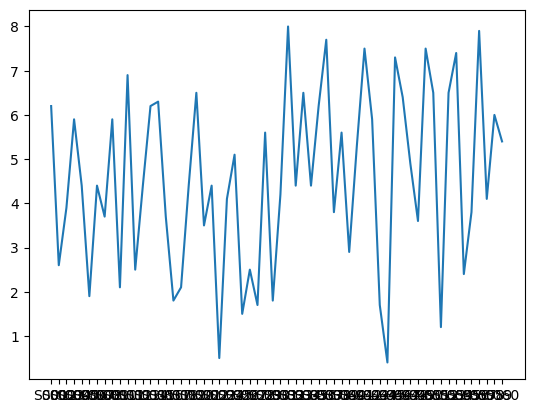

In [42]:
# To identify clusters of students who consistently study very little versus those who study a lot,
# plot study hours across all 60 student IDs in order. Which chart makes such clustering visible?
plt.plot(df["Student ID"],df["Study Hours/Day"])